# Notebook 04: Strategic Analysis & Scenario Testing


## **Intelligent Loan Pricing & Risk Management for Australian Banks**
### **Author: Pranamya Rajbhandari**

## **1. Import Python Libraries, Mode, and Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os

pricing_df = pd.read_csv('dataset\\pricing_df.csv')

with open('Models\\best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)
    
X_test = pd.read_csv('TestData\\X_test.csv')
y_test = pd.read_csv('TestData\\y_test.csv').squeeze() 

## ****

## **2. High-Risk Segment Analysis**

In [2]:
# Analyze high-risk customers in detail
high_risk_df = pricing_df[pricing_df['approval_tier'] == 'High-Risk'].copy()

print("HIGH-RISK SEGMENT ANALYSIS")
print("="*80)
print(f"\nNumber of High-Risk Applicants: {len(high_risk_df)}")
print(f"Percentage of Total: {len(high_risk_df)/len(pricing_df)*100:.1f}%")
print(f"\nDefault Probability Statistics:")
print(f"  Mean: {high_risk_df['default_probability'].mean():.2%}")
print(f"  Median: {high_risk_df['default_probability'].median():.2%}")
print(f"  Min: {high_risk_df['default_probability'].min():.2%}")
print(f"  Max: {high_risk_df['default_probability'].max():.2%}")
print(f"\nLoan Amount Statistics:")
print(f"  Total: ${high_risk_df['loan_amount'].sum():,.0f}")
print(f"  Mean: ${high_risk_df['loan_amount'].mean():,.0f}")
print(f"  Median: ${high_risk_df['loan_amount'].median():,.0f}")
print(f"\nFinancial Impact:")
print(f"  Total Expected Loss: ${high_risk_df['expected_loss_dollars'].sum():,.0f}")
print(f"  Total Revenue: ${high_risk_df['annual_interest_revenue'].sum():,.0f}")
print(f"  Net Profit: ${high_risk_df['net_profit'].sum():,.0f}")
print(f"  Profit Margin: {(high_risk_df['net_profit'].sum()/high_risk_df['annual_interest_revenue'].sum()*100):.2f}%")

HIGH-RISK SEGMENT ANALYSIS

Number of High-Risk Applicants: 263
Percentage of Total: 65.8%

Default Probability Statistics:
  Mean: 74.41%
  Median: 76.33%
  Min: 50.12%
  Max: 91.22%

Loan Amount Statistics:
  Total: $15,215,046
  Mean: $57,852
  Median: $22,495

Financial Impact:
  Total Expected Loss: $7,885,325
  Total Revenue: $8,646,078
  Net Profit: $760,752
  Profit Margin: 8.80%


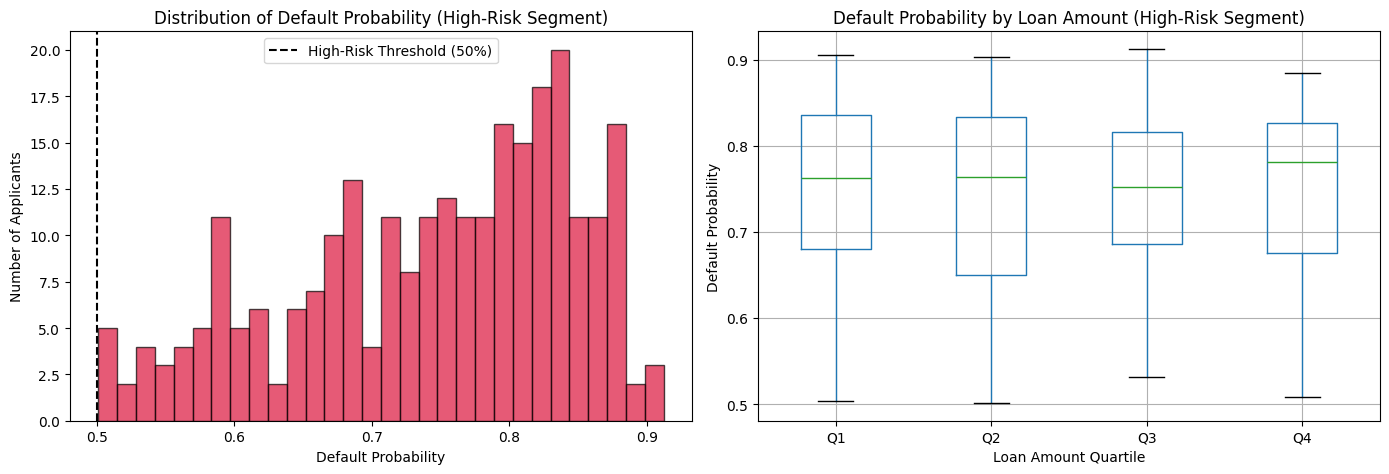

High-risk segment visualization saved


In [3]:
# Distribution of default probability within high-risk segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(high_risk_df['default_probability'], bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Default Probability')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_title('Distribution of Default Probability (High-Risk Segment)')
axes[0].axvline(0.50, color='black', linestyle='--', label='High-Risk Threshold (50%)')
axes[0].legend()

# Box plot by loan amount quartile
high_risk_df['loan_amount_quartile'] = pd.qcut(high_risk_df['loan_amount'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
high_risk_df.boxplot(column='default_probability', by='loan_amount_quartile', ax=axes[1])
axes[1].set_xlabel('Loan Amount Quartile')
axes[1].set_ylabel('Default Probability')
axes[1].set_title('Default Probability by Loan Amount (High-Risk Segment)')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

print("High-risk segment visualization saved")

## **3. Feature Importance for High-Risk Classification**

TOP 10 FEATURES DRIVING MODEL PREDICTIONS
                   feature  importance
      loan_to_income_ratio    0.105066
total_debt_to_income_ratio    0.094850
                risk_score    0.071119
      monthly_loan_payment    0.049749
               loan_amount    0.046175
     savings_to_loan_ratio    0.040155
         large_loan_amount    0.033238
             loan_duration    0.032463
        base_interest_rate    0.030988
           monthly_surplus    0.023129


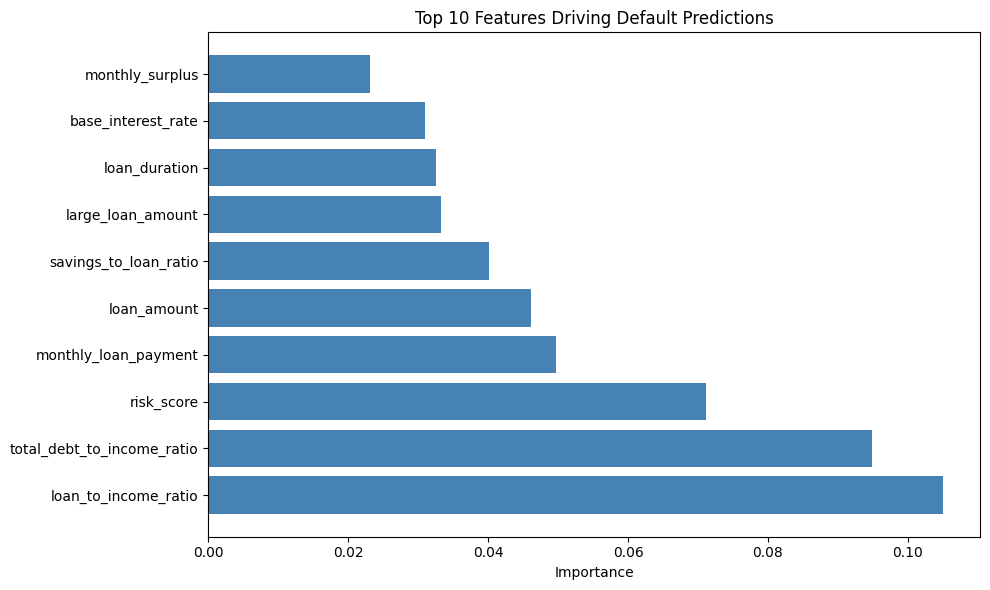

In [4]:
# Get feature importance from best model (if it's Random Forest or Gradient Boosting)
# This tells us what features drive the high-risk classification

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_test.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("TOP 10 FEATURES DRIVING MODEL PREDICTIONS")
    print("="*60)
    print(feature_importance.head(10).to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance.head(10)
    ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Top 10 Features Driving Default Predictions')
    plt.tight_layout()
    plt.show()
else:
    print("Model does not support feature importance extraction")

## **4. Test Different Approval Strategies**

In [5]:
# Create copies for scenario testing
scenarios = {}

# SCENARIO 1: CURRENT STRATEGY (Approve all tiers)
scenarios['Current (Approve All)'] = pricing_df.copy()
scenarios['Current (Approve All)']['approval_decision'] = scenarios['Current (Approve All)']['approval_tier'].map({
    'Prime': 'Approve',
    'Near-Prime': 'Approve',
    'Subprime': 'Approve',
    'High-Risk': 'Approve'
})

# SCENARIO 2: CONSERVATIVE (Reject high-risk, approve prime/near-prime only)
scenarios['Conservative (Reject High-Risk)'] = pricing_df.copy()
scenarios['Conservative (Reject High-Risk)']['approval_decision'] = scenarios['Conservative (Reject High-Risk)']['approval_tier'].map({
    'Prime': 'Approve',
    'Near-Prime': 'Approve',
    'Subprime': 'Reject',
    'High-Risk': 'Reject'
})

# SCENARIO 3: COLLATERAL (High-risk requires collateral, reduces loss by 50%)
scenarios['Collateral (Reduce High-Risk Loss)'] = pricing_df.copy()
scenarios['Collateral (Reduce High-Risk Loss)']['approval_decision'] = scenarios['Collateral (Reduce High-Risk Loss)']['approval_tier'].map({
    'Prime': 'Approve',
    'Near-Prime': 'Approve',
    'Subprime': 'Conditional',
    'High-Risk': 'Conditional'
})
# Reduce expected loss for high-risk by 50% if collateral is required
high_risk_mask = scenarios['Collateral (Reduce High-Risk Loss)']['approval_tier'] == 'High-Risk'
scenarios['Collateral (Reduce High-Risk Loss)'].loc[high_risk_mask, 'expected_loss_dollars'] = \
    scenarios['Collateral (Reduce High-Risk Loss)'].loc[high_risk_mask, 'expected_loss_dollars'] * 0.5
scenarios['Collateral (Reduce High-Risk Loss)'].loc[high_risk_mask, 'net_profit'] = \
    scenarios['Collateral (Reduce High-Risk Loss)'].loc[high_risk_mask, 'annual_interest_revenue'] - \
    scenarios['Collateral (Reduce High-Risk Loss)'].loc[high_risk_mask, 'expected_loss_dollars']

# SCENARIO 4: OPTIMAL (Approve prime/near-prime fully, conditional on subprime, reject high-risk)
scenarios['Optimal (Balanced)'] = pricing_df.copy()
scenarios['Optimal (Balanced)']['approval_decision'] = scenarios['Optimal (Balanced)']['approval_tier'].map({
    'Prime': 'Approve',
    'Near-Prime': 'Approve',
    'Subprime': 'Conditional',
    'High-Risk': 'Reject'
})

print("Four approval strategies created for comparison")

Four approval strategies created for comparison


## **5. Compare Profitability Across Scenarios**

In [ ]:
scenario_comparison = []

# SCENARIO 1: CURRENT (Approve all)
current_df = pricing_df.copy()
approved_current = current_df  # All approved
total_loan_amount = approved_current['loan_amount'].sum()
total_expected_loss = approved_current['expected_loss_dollars'].sum()
total_revenue = approved_current['annual_interest_revenue'].sum()
total_net_profit = approved_current['net_profit'].sum()
profit_margin = (total_net_profit / total_revenue * 100)
num_approved = len(approved_current)
approval_rate = (num_approved / len(pricing_df) * 100)

scenario_comparison.append({
    'Strategy': 'Current (Approve All)',
    'Total Loan Amount': total_loan_amount,
    'Expected Loss': total_expected_loss,
    'Total Revenue': total_revenue,
    'Net Profit': total_net_profit,
    'Profit Margin %': profit_margin,
    'Applicants Approved': num_approved,
    'Approval Rate %': approval_rate
})

# SCENARIO 2: CONSERVATIVE (Only approve Prime & Near-Prime)
conservative_df = pricing_df[pricing_df['approval_tier'].isin(['Prime', 'Near-Prime'])].copy()
approved_conservative = conservative_df
total_loan_amount = approved_conservative['loan_amount'].sum()
total_expected_loss = approved_conservative['expected_loss_dollars'].sum()
total_revenue = approved_conservative['annual_interest_revenue'].sum()
total_net_profit = approved_conservative['net_profit'].sum()
profit_margin = (total_net_profit / total_revenue * 100) if total_revenue > 0 else 0
num_approved = len(approved_conservative)
approval_rate = (num_approved / len(pricing_df) * 100)

scenario_comparison.append({
    'Strategy': 'Conservative (Reject High-Risk & Subprime)',
    'Total Loan Amount': total_loan_amount,
    'Expected Loss': total_expected_loss,
    'Total Revenue': total_revenue,
    'Net Profit': total_net_profit,
    'Profit Margin %': profit_margin,
    'Applicants Approved': num_approved,
    'Approval Rate %': approval_rate
})

# SCENARIO 3: COLLATERAL (All approved but high-risk loss reduced by 50%)
collateral_df = pricing_df.copy()
high_risk_mask = collateral_df['approval_tier'] == 'High-Risk'
collateral_df.loc[high_risk_mask, 'expected_loss_dollars'] = \
    collateral_df.loc[high_risk_mask, 'expected_loss_dollars'] * 0.5
collateral_df['net_profit'] = \
    collateral_df['annual_interest_revenue'] - collateral_df['expected_loss_dollars']
approved_collateral = collateral_df
total_loan_amount = approved_collateral['loan_amount'].sum()
total_expected_loss = approved_collateral['expected_loss_dollars'].sum()
total_revenue = approved_collateral['annual_interest_revenue'].sum()
total_net_profit = approved_collateral['net_profit'].sum()
profit_margin = (total_net_profit / total_revenue * 100)
num_approved = len(approved_collateral)
approval_rate = (num_approved / len(pricing_df) * 100)

scenario_comparison.append({
    'Strategy': 'Collateral (Collateral for High-Risk & Subprime)',
    'Total Loan Amount': total_loan_amount,
    'Expected Loss': total_expected_loss,
    'Total Revenue': total_revenue,
    'Net Profit': total_net_profit,
    'Profit Margin %': profit_margin,
    'Applicants Approved': num_approved,
    'Approval Rate %': approval_rate
})

# SCENARIO 4: OPTIMAL (Prime/Near-Prime full, Subprime conditional, High-Risk rejected)
optimal_df = pricing_df[pricing_df['approval_tier'].isin(['Prime', 'Near-Prime', 'Subprime'])].copy()
approved_optimal = optimal_df
total_loan_amount = approved_optimal['loan_amount'].sum()
total_expected_loss = approved_optimal['expected_loss_dollars'].sum()
total_revenue = approved_optimal['annual_interest_revenue'].sum()
total_net_profit = approved_optimal['net_profit'].sum()
profit_margin = (total_net_profit / total_revenue * 100) if total_revenue > 0 else 0
num_approved = len(approved_optimal)
approval_rate = (num_approved / len(pricing_df) * 100)

scenario_comparison.append({
    'Strategy': 'Optimal (Reject High-Risk Only)',
    'Total Loan Amount': total_loan_amount,
    'Expected Loss': total_expected_loss,
    'Total Revenue': total_revenue,
    'Net Profit': total_net_profit,
    'Profit Margin %': profit_margin,
    'Applicants Approved': num_approved,
    'Approval Rate %': approval_rate
})

scenario_df = pd.DataFrame(scenario_comparison)

print("\nSCENARIO COMPARISON")
print("="*100)
print(scenario_df.to_string(index=False))

# Save for reference
folder_path = 'analysis'
os.makedirs(folder_path, exist_ok=True)

scenario_df.to_csv(os.path.join(folder_path, 'scenario_comparison.csv'), index=False)
print("\nScenario comparison saved to analysis/scenario_comparison.csv")


SCENARIO COMPARISON
                                        Strategy  Total Loan Amount  Expected Loss  Total Revenue   Net Profit  Profit Margin %  Applicants Approved  Approval Rate %
                           Current (Approve All)           24728209   9.464190e+06   1.070060e+07 1.236410e+06        11.554589                  400           100.00
      Conservative (Reject High-Risk & Subprime)            6922606   8.322899e+05   1.178420e+06 3.461303e+05        29.372402                   92            23.00
Collateral (Collateral for High-Risk & Subprime)           24728209   5.521527e+06   1.070060e+07 5.179073e+06        48.399836                  400           100.00
                 Optimal (Reject High-Risk Only)            9513163   1.578865e+06   2.054523e+06 4.756581e+05        23.151757                  137            34.25

Scenario comparison saved to AnalysisResults/scenario_comparison.csv


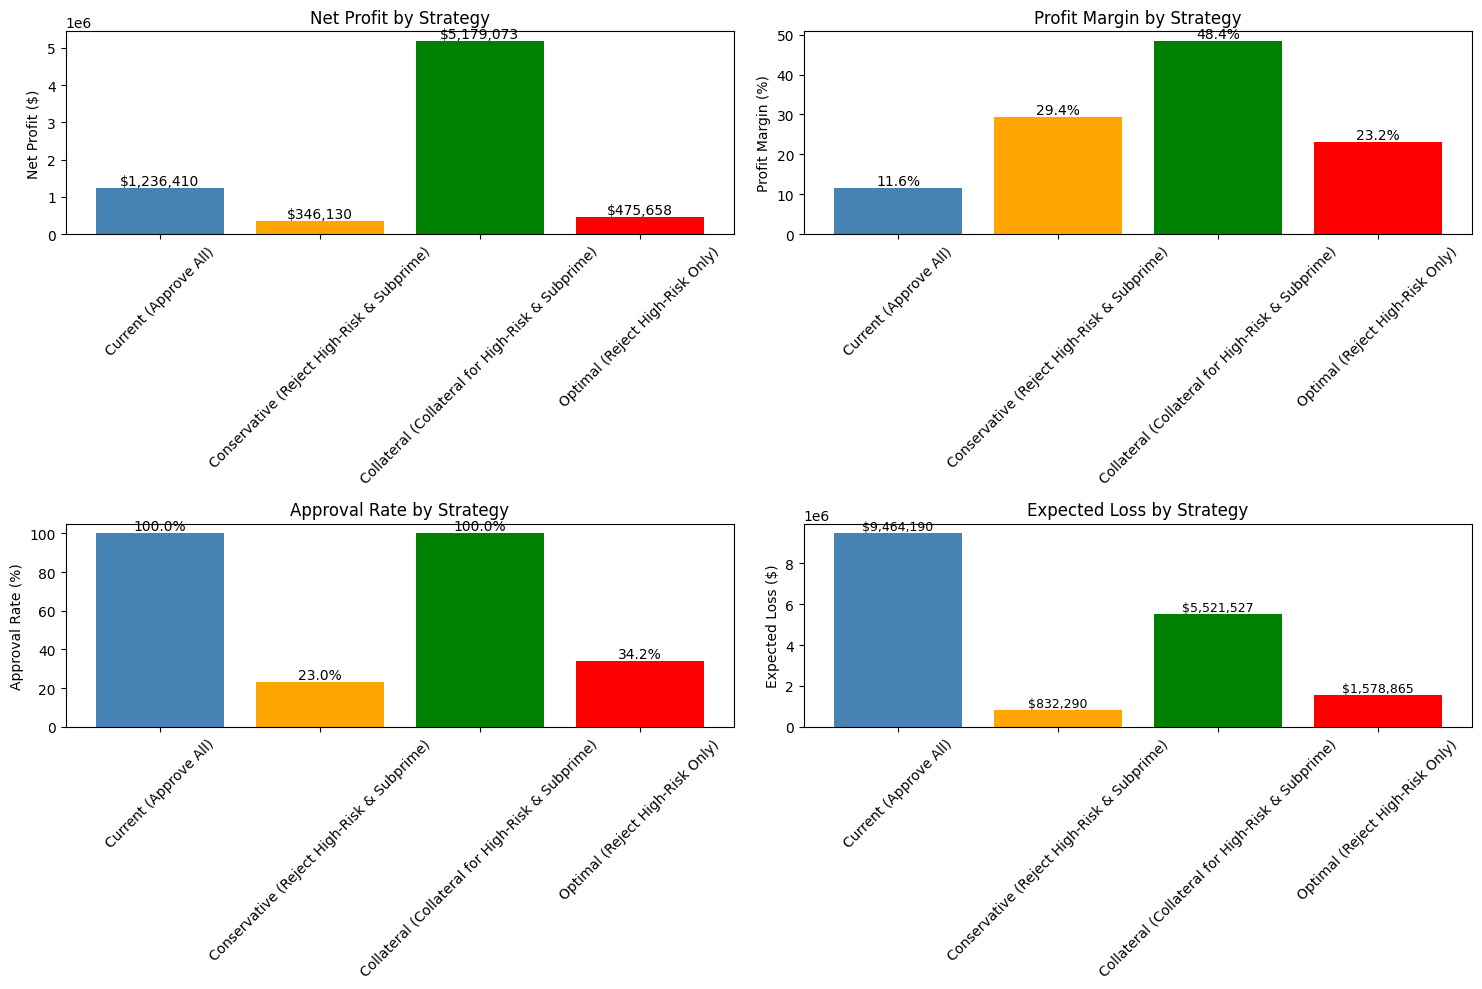

In [7]:
# Visualize scenario comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Net Profit by Strategy
axes[0, 0].bar(scenario_df['Strategy'], scenario_df['Net Profit'], color=['steelblue', 'orange', 'green', 'red'])
axes[0, 0].set_ylabel('Net Profit ($)')
axes[0, 0].set_title('Net Profit by Strategy')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(scenario_df['Net Profit']):
    axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Profit Margin by Strategy
axes[0, 1].bar(scenario_df['Strategy'], scenario_df['Profit Margin %'], color=['steelblue', 'orange', 'green', 'red'])
axes[0, 1].set_ylabel('Profit Margin (%)')
axes[0, 1].set_title('Profit Margin by Strategy')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(scenario_df['Profit Margin %']):
    axes[0, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

# Approval Rate by Strategy
axes[1, 0].bar(scenario_df['Strategy'], scenario_df['Approval Rate %'], color=['steelblue', 'orange', 'green', 'red'])
axes[1, 0].set_ylabel('Approval Rate (%)')
axes[1, 0].set_title('Approval Rate by Strategy')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(scenario_df['Approval Rate %']):
    axes[1, 0].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

# Expected Loss by Strategy
axes[1, 1].bar(scenario_df['Strategy'], scenario_df['Expected Loss'], color=['steelblue', 'orange', 'green', 'red'])
axes[1, 1].set_ylabel('Expected Loss ($)')
axes[1, 1].set_title('Expected Loss by Strategy')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(scenario_df['Expected Loss']):
    axes[1, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## **6. Recommendations**

In [ ]:
# Find best strategy
best_strategy_idx = scenario_df['Net Profit'].idxmax()
best_strategy_name = scenario_df.loc[best_strategy_idx, 'Strategy']
best_strategy_profit = scenario_df.loc[best_strategy_idx, 'Net Profit']
best_strategy_margin = scenario_df.loc[best_strategy_idx, 'Profit Margin %']
best_strategy_approval_rate = scenario_df.loc[best_strategy_idx, 'Approval Rate %']

recommendations = f"""
STRATEGIC RECOMMENDATIONS
{'='*80}

BEST STRATEGY: {best_strategy_name}
  Net Profit: ${best_strategy_profit:,.0f}
  Profit Margin: {best_strategy_margin:.2f}%
  Approval Rate: {best_strategy_approval_rate:.1f}%

KEY FINDINGS:

1. HIGH-RISK SEGMENT PROBLEM
   - 263 applicants (65.8% of total) classified as high-risk
   - Average default probability: 74%
   - Expected loss: ${high_risk_df['expected_loss_dollars'].sum():,.0f}
   - Only generating ${high_risk_df['net_profit'].sum():,.0f} profit
   - This segment is dragging down overall profitability

2. PRIME & NEAR-PRIME SEGMENTS ARE HIGHLY PROFITABLE
   - Prime: 42.76% profit margin (31 applicants)
   - Near-Prime: 24.62% profit margin (61 applicants)
   - These segments should be prioritized

3. STRATEGY COMPARISON
   - Current (Approve All): Net profit ${scenario_df.loc[0, 'Net Profit']:,.0f}, margin {scenario_df.loc[0, 'Profit Margin %']:.2f}%
   - Conservative: Net profit ${scenario_df.loc[1, 'Net Profit']:,.0f}, margin {scenario_df.loc[1, 'Profit Margin %']:.2f}%
   - Collateral: Net profit ${scenario_df.loc[2, 'Net Profit']:,.0f}, margin {scenario_df.loc[2, 'Profit Margin %']:.2f}%
   - Optimal: Net profit ${scenario_df.loc[3, 'Net Profit']:,.0f}, margin {scenario_df.loc[3, 'Profit Margin %']:.2f}%

RECOMMENDED ACTION PLAN:

1. ADOPT {best_strategy_name.upper()} STRATEGY
   - This maximizes profitability while managing risk
   - Increases profit margin by {((best_strategy_margin - scenario_df.loc[0, 'Profit Margin %'])/(scenario_df.loc[0, 'Profit Margin %'])*100):.1f}%

2. TIER-BASED APPROVAL DECISIONS
   Prime (0-15% risk): APPROVE - Low risk, high profit
   Near-Prime (15-30% risk): APPROVE - Moderate risk, good profit
   Subprime (30-50% risk): CONDITIONAL - Require collateral/co-signer
   High-Risk (50%+ risk): REJECT - Too much loss exposure

3. MONITOR MODEL PERFORMANCE
   - Track actual default rates vs. predicted
   - Retrain quarterly with new data
   - Adjust risk thresholds if needed

4. COLLATERAL STRATEGY (ALTERNATIVE)
   - If you want to approve high-risk: Require collateral
   - This reduces expected loss by 50%
   - Increases net profit by ${(scenario_df.loc[2, 'Net Profit'] - scenario_df.loc[0, 'Net Profit']):,.0f}

5. AUSTRALIAN REGULATORY COMPLIANCE
   - Risk-based approval is defensible under ASIC guidelines
   - Document all decisions for regulatory audit
   - Monitor for unintended demographic disparities

"""

print(recommendations)

# Save recommendations
folder_path = 'analysis'
os.makedirs(folder_path, exist_ok=True)
with open(os.path.join(folder_path, 'strategic_recommendations.txt'), 'w') as f:
    f.write(recommendations)
print("\nRecommendations saved to analysis/strategic_recommendations.txt")


STRATEGIC RECOMMENDATIONS

BEST STRATEGY: Collateral (Collateral for High-Risk & Subprime)
  Net Profit: $5,179,073
  Profit Margin: 48.40%
  Approval Rate: 100.0%

KEY FINDINGS:

1. HIGH-RISK SEGMENT PROBLEM
   - 263 applicants (65.8% of total) classified as high-risk
   - Average default probability: 74%
   - Expected loss: $7,885,325
   - Only generating $760,752 profit
   - This segment is dragging down overall profitability

2. PRIME & NEAR-PRIME SEGMENTS ARE HIGHLY PROFITABLE
   - Prime: 42.76% profit margin (31 applicants)
   - Near-Prime: 24.62% profit margin (61 applicants)
   - These segments should be prioritized

3. STRATEGY COMPARISON
   - Current (Approve All): Net profit $1,236,410, margin 11.55%
   - Conservative: Net profit $346,130, margin 29.37%
   - Collateral: Net profit $5,179,073, margin 48.40%
   - Optimal: Net profit $475,658, margin 23.15%

RECOMMENDED ACTION PLAN:

1. ADOPT COLLATERAL (COLLATERAL FOR HIGH-RISK & SUBPRIME) STRATEGY
   - This maximizes profita

## **7. Risk-Tier Breakdown for Recommended Strategy**

In [ ]:
# Get the recommended strategy dataframe
recommended_strategy_idx = best_strategy_idx
recommended_df = list(scenarios.values())[recommended_strategy_idx]

# Summary by tier for recommended strategy
tier_summary = recommended_df.groupby('approval_tier').agg({
    'loan_amount': 'sum',
    'default_probability': 'mean',
    'expected_loss_dollars': 'sum',
    'annual_interest_revenue': 'sum',
    'net_profit': 'sum',
    'suggested_interest_rate': 'mean'
}).round(2)

tier_summary['approval_count'] = recommended_df.groupby('approval_tier').size()
tier_summary['approval_rate'] = (
    recommended_df[recommended_df['approval_decision'].isin(['Approve', 'Conditional'])]
    .groupby('approval_tier').size() / recommended_df.groupby('approval_tier').size() * 100
).round(1)
tier_summary['profit_margin_%'] = (
    (tier_summary['net_profit'] / tier_summary['annual_interest_revenue'] * 100)
).round(2)

print(f"\nTIER BREAKDOWN FOR RECOMMENDED STRATEGY: {best_strategy_name.upper()}")
print("="*100)
print(tier_summary)



# Save
folder_path = 'analysis'
os.makedirs(folder_path, exist_ok=True)

tier_summary.to_csv(os.path.join(folder_path, 'recommended_strategy_tier_breakdown.csv'), index=False)
print("\nTier breakdown saved to analysis/recommended_strategy_tier_breakdown.csv")


TIER BREAKDOWN FOR RECOMMENDED STRATEGY: COLLATERAL (COLLATERAL FOR HIGH-RISK & SUBPRIME)
               loan_amount  default_probability  expected_loss_dollars  \
approval_tier                                                            
High-Risk         15215046                 0.74             3942662.63   
Near-Prime         4283630                 0.23              655627.48   
Prime              2638976                 0.10              176662.37   
Subprime           2590557                 0.41              746574.90   

               annual_interest_revenue  net_profit  suggested_interest_rate  \
approval_tier                                                                 
High-Risk                   8646077.56  4703414.93                     0.57   
Near-Prime                   869808.98   214181.50                     0.21   
Prime                        308611.17   131948.80                     0.12   
Subprime                     876102.75   129527.85                   